 <h1><font style="color:blue">Project 2: Kaggle Competition - Classification</font> </h1>

#### Maximum Points: 100

<div><h5>
    <table>
        <tr><td>#</td><td>Section</td> <td>Points</td> </tr>
        <tr><td>1</td> <td>Data Loader</td> <td>10</td> </tr>
        <tr><td>2</td> <td>Configuration</td> <td>5</td> </tr>
        <tr><td>3</td> <td>Evaluation Metric</td> <td>10</td> </tr>
        <tr><td>4</td> <td>Train and Validation</td> <td>5</td> </tr>
        <tr><td>5</td> <td>Model</td> <td>5</td> </tr>
        <tr><td>6</td> <td>Utils</td> <td>5</td> </tr>
        <tr><td>7</td> <td>Experiment</td><td>5</td> </tr>
        <tr><td>8</td> <td>TensorBoard Log</td> <td>5</td> </tr>
        <tr><td>9</td> <td>Kaggle Profile Link</td> <td>50</td> </tr>
    </table>
<h5></div>


In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:98% !important; }</style>"))
%load_ext autoreload  
%autoreload 2
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
import os
import tomllib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wandb
import sys 
import gc
for p in ['../..']:
    if p not in sys.path:
        # print(f"insert {p}")
        sys.path.insert(0, p)
print(sys.path)


['../..', '/home/kbardool/miniconda3/envs/opencv/lib/python312.zip', '/home/kbardool/miniconda3/envs/opencv/lib/python3.12', '/home/kbardool/miniconda3/envs/opencv/lib/python3.12/lib-dynload', '', '/home/kbardool/miniconda3/envs/opencv/lib/python3.12/site-packages']


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms.functional as TVF
# import torch.utils.data as data
# import torch.optim.lr_scheduler as lr_scheduler
# from torchvision import transforms
# from torch.utils.data import Dataset, DataLoader
import lightning as L
 
from torchinfo import summary

from torch.utils.tensorboard import SummaryWriter

# Use torchmetrics API to track and compute metrics automatically
# from torchmetrics import MeanMetric    # Aggregate a stream of value into their mean value.
# from torchmetrics.classification import MulticlassAccuracy # Compute Accuracy for multiclass tasks.
# from torch.utils.tensorboard import SummaryWriter

pd.set_option('display.width',180)
torch.set_printoptions(linewidth=180)
np.set_printoptions(linewidth=180)

In [4]:
# from training_code import *
# from models_code import  PretrainedResNet34, PretrainedResNet101
from data_code import KenyanFoodDataModule
from models_code import  PretrainedResNet50, pretrained_resnet50 
from training_code import denormalize, display_images, load_checkpoint, save_checkpoint
from training_code import SystemConfiguration,TrainingConfiguration, InferenceConfiguration
from training_code import Metrics


In [5]:
# NOTEBOOK_NAME = os.path.basename(os.environ.get('JPY_SESSION_NAME'))
NOTEBOOK_NAME = "Copy1_training.ipynb"
print(f"Notebook name : {NOTEBOOK_NAME}")
os.environ["WANDB_NOTEBOOK_NAME"] = NOTEBOOK_NAME


Notebook name : Copy1_training.ipynb


<h1> <font style="color:green"> Helper Code </font></h1>

In [6]:
def delete_vars(variables = ['model',  'metrics', 'train_config', 'sys_config', 'optimizer', 'scheduler', 'train_loader', 'val_loader', 'data_module']):
    for vr in variables:
        global_vars = globals()
        if vr in global_vars:
            try:
                del globals()[vr]
                print(f" {vr:15s} deleted . . . ")
            except Exception as e:
                print(e)
        else:
            print(f" {vr:15s} NOT defined . . .")
    
    print(f" gc.collect() : {gc.collect()}")
    print(f" Cuda empty cache : {torch.cuda.empty_cache()}")


<h1> <font style="color:green">Data Loader [10 Points]</h1></font>

In this section, you have to write a class or methods, which will be used to get training and validation data loader.You need to write a custom dataset class to load data.

**Note; There is   no separate validation data. , You will thus have to create your own validation set, by dividing the train data into train and validation data. Usually, we do 80:20 ratio for train and validation, respectively.**


For example:

```python
class KenyanFood13Dataset(Dataset):
    """    
    """
    
    def __init__(self, *args):
    ...
    
    def __getitem__(self, idx):
    ...    
```

```python
def get_data(args1, *agrs):
    ....
    ....
    return train_loader, test_loader
```

## Kenyan Food dataset

In [ ]:
# from data_code import KenyanFoodDataset

## Kenyan Food PyTorch Lightning DataModule Definition

In [ ]:
# from data_code import KenyanFoodDataModule

## Test Dataset and Data Module

In [ ]:
delete_vars()
gc.collect()

In [ ]:
# data loader
data_module = KenyanFoodDataModule(
    data_root = './images', 
    batch_size = 12,
    num_workers = 2,
    image_shape = 224,
    class_boost =  np.array([1., 1., 1., 1., 3., 1., 1., 1., 1., 1., 1., 1., 1.]),
    augmentation = 'V5',
    pin_memory=True,
    seed=84
)
data_module.prepare_data()
data_module.setup()
# train_loader = data_module.train_dataloader()
# val_loader = data_module.val_dataloader()

In [ ]:
len(data_module.train_dataset.data_dict)
iter_trn_loader = iter(data_module.train_dataloader())

# len(data_module.val_dataset.data_dict)
# iter_val_loader = iter(data_module.val_dataloader())

# len(data_module.test_dataset.data_dict)
# iter_tst_loader = iter(data_module.test_dataloader())
# data_module.label_to_name

In [ ]:
# display_class_images(denormed_images, labels, names, filter= 9)
# display_class_images(denormed_images, labels, names, filter= 4)

In [ ]:
images, labels = next(iter_trn_loader)
names = [data_module.label_to_name[x] for x in labels.numpy()]
print("labels: ", labels)
print("names : ", names)
denormed_images = denormalize(images)

display_images(denormed_images, labels, names)
# display_images(images, labels, names)

In [ ]:
images, labels = next(iter_trn_loader)
names = [data_module.label_to_name[x] for x in labels.numpy()]
print("labels: ", labels)
print("names : ", names)
denormed_images = denormalize(images)

display_images(denormed_images, labels, names)
# display_images(images, labels, names)

### Validation Dataset

In [ ]:
len(data_module.val_dataset.data_dict)
iter_val_loader = iter(data_module.val_dataloader())

In [ ]:
images, labels = next(iter_val_loader)
denormed_images = denormalize(images)
names = [data_module.label_to_name[x] for x in labels.numpy()]
print("labels: ", labels)
print("names : ", names)

display_images(denormed_images, labels, names)
display_images(images, labels, names)

In [ ]:
images, labels = next(iter_val_loader)
denormed_images = denormalize(images)
names = [data_module.label_to_name[x] for x in labels.numpy()]
print("labels: ", labels)
print("names : ", names)


display_images(denormed_images, labels, names)
display_images(images, labels, names)

In [ ]:
# idx = 8
# display_image(images[idx], lbl = 0 )
# display_image(denormalize(images[idx], mean, std), lbl = 0 )

In [ ]:
# t_images = next(iter_tst_loader)

# display_images(t_images)
# display_images(normalize_transform(t_images))

In [ ]:
# del data_module

**Predefined methods and their usage:**


- **`prepare_data`:** This method is used for data preparation like  downloading and one-time preprocessing with the dataset. When  training on a distributed GPU, this will be called from a single GPU. So do not update or initiate attributes in this method. (Note: Do not do - `self.x = y`).


- **`setup`:** When you want to perform data operations on every GPU, this method is apt for it will call from every GPU. For example, perform train/val/test splits. 


- **`train_dataloader`:** This method returns dataloader with train dataset. 


- **`val_dataloader(s)`:** This method returns dataloader(s) with the validation dataset.


- **`test_dataloader(s)`:** This method returns dataloader(s) with the test dataset.


Get details of `LightningDataModule`<a href="https://pytorch-lightning.readthedocs.io/en/stable/extensions/datamodules.html" target="_blank">here</a>.

<h1><font style="color:green"> Configuration [5 Points]</font></h2>

**Define your configuration here.**

For example:

```python
@dataclass
class TrainingConfiguration:
    '''
    Describes configuration of the training process
    '''
    batch_size: int = 10 
    epochs_count: int = 50  
    learning_rate: float = 0.1  # initial learning rate for lr scheduler
    log_interval: int = 5  
    test_interval: int = 1  
    data_root: str = "/kaggle/input/opencv-pytorch-classification-project-2/" 
    num_workers: int = 2  
    device: str = 'cuda'      
```

In [ ]:
# from training_code import SystemConfiguration

# from training_code import TrainingConfiguration

# from training_code import Metrics

<font style="color:green"><h1>Evaluation Metric [10 Points]</h1></font>

**Define methods or classes that will be used in model evaluation. For example, accuracy, f1-score etc.**

<font style="color:green"> <h1>Train and Validation [5 Points]</h1></font>


**Write the methods or classes to be used for training and validation.**

# <font style="color:green">Model [5 Points]</font>

**Define your model in this section.**

**You are allowed to use any pre-trained model.**

In [ ]:
# model =  pretrained_resnet50(finetune=['fc', 'layer4', 'layer3', 'layer2'])
# model = pretrained_resnet34()
# model = pretrained_resnet50(finetune=['fc', 'layer4', 'layer3', 'layer2'])
# metrics = Metrics()

In [ ]:
# print(model.resnet.fc.in_features)
# print(model.resnet.fc.out_features)

# print(model.name)
# print_model_summary(model.resnet) 

# for param in model.named_parameters():
#     print(f"{param[0]:35s}, {param[1].shape}, {param[1].requires_grad}")
#     # print(param)

# layers = list(model.resnet.children())
# layers = list(model.resnet.named_children())
# layers = list(model.resnet.named_modules())
# for layer  in layers:
#     print('\n'+'='*100)
#     print(layer[0], type(layer[1]))
# #     # print(layer[1].weight)
# #     print(f"{layer.weight.shape}, {type(layer)}")
#     print('='*100+'\n')


In [ ]:
# resnet = pretrained_resnet50()
# print(type(resnet))   

In [ ]:
# print(resnet)
# print_model_summary(resnet)
# for param in resnet.parameters():
#      print(param.shape, param.requires_grad)

# resnet.fc.in_features
# resnet.layer1
# del resnet

In [ ]:
# layers = list(resnet50.children())
# for layer  in layers[:-1]:
#     print('\n'+'='*100)
#     print(layer)
#     print('='*100+'\n')
# print(layers[-1])

In [ ]:
class  pretrained_resnet50_fc2(nn.Module):
    
    def __init__(self,num_classes=13, 
                 finetune = ['fc'], p = 0.2,
                 weights=models.ResNet50_Weights.IMAGENET1K_V2):
    
        super().__init__()
        self.name = "resnet50"
        self.p = p
        self.finetune =finetune        
        self.tuning_layers = ''.join(['fc']+sorted([x[-1] for x in self.finetune if (x[:-1]=='layer' and x != 'fc')], reverse=True))
        self.tuning_layers= 'fc2'+self.tuning_layers
        
        # init a pretrained resnet
        self.resnet = models.resnet50(weights=weights)
        last_layer_in = self.resnet.fc.in_features
        self.resnet.fc = nn.Linear(in_features=last_layer_in, out_features=last_layer_in//4)
        self.resnet.fc_relu = nn.ReLU(inplace=True)
        self.resnet.dropout = nn.Dropout(p=self.p)
        self.resnet.fc2 = nn.Linear(last_layer_in //4, num_classes)
        
        for param in self.resnet.parameters():
            param.requires_grad = False
        
        for ft_layer in finetune:
            print(f" Turn on gradients for layer [{ft_layer}]")
            layer = getattr(self.resnet, ft_layer)
            # print(layer)
            for param in layer.named_parameters():
                print(f"     -  param : {param[0]:35s}  Shape: {param[1].shape}  Requires Grad: {param[1].requires_grad}",end ='')
                param[1].requires_grad = True
                print(f"  ---> {param[1].requires_grad}")
            print()
            
    def forward(self, x):
        x = self.resnet(x)
        x = self.resnet.fc_relu(x)
        x = self.resnet.dropout(x)
        x = self.resnet.fc2(x)
        return x


In [ ]:
# model = PretrainedResNet101(finetune=['fc', 'layer4', 'layer3'])
# model = pretrained_resnet50(finetune=['fc2','fc', 'layer4', 'layer3'])

In [ ]:
# print(type(model.resnet))
# print(model)
# print_model_summary(model)

# <font style="color:green">Utils [5 Points]</font>

**Define those methods or classes, which have  not been covered in the above sections.**

# <font style="color:green">Experiment [5 Points]</font>

**Choose your optimizer and LR-scheduler and use the above methods and classes to train your model.**

In [5]:
timestamp = datetime.now().strftime('%Y_%m_%d_%H:%M:%S')
logger = logging.getLogger(__name__) 
logLevel = os.environ.get('LOG_LEVEL', 'INFO').upper()
FORMAT = '%(asctime)s - %(name)s - %(levelname)s: - %(message)s'
logging.basicConfig(level="INFO", format= FORMAT)

logger.info(f" Excution started : {timestamp} ")
logger.info(f" Pytorch version  : {torch.__version__}  \t\t Number of threads: {torch.get_num_threads()}")
logger.info(f" WandB version    : {wandb.__version__}  \t\t Pandas version: {pd.__version__}  ")
# logger.info(f" Scipy version    : {scipy.__version__}  \t\t Numpy version : {np.__version__}")
# logger.info(f" Search path      : {sys.path}")

2026-02-24 13:10:25,207 - __main__ - INFO: -  Excution started : 2026_02_24_13:10:25 
2026-02-24 13:10:25,209 - __main__ - INFO: -  Pytorch version  : 2.9.1  		 Number of threads: 6
2026-02-24 13:10:25,210 - __main__ - INFO: -  WandB version    : 0.23.1  		 Pandas version: 2.3.3  


In [6]:
delete_vars()
gc.collect()

NameError: name 'delete_vars' is not defined

In [6]:
SESSION_NAME = NOTEBOOK_NAME.split('.')[0]
print(SESSION_NAME)

BATCH_SIZE   = 96
EPOCHS_COUNT = 160
WEIGHT_DECAY = 7.5e-03
LR_FACTOR    = 0.85
LR_PATIENCE  = 3
LR_COOLDOWN  = 1
SCHEDULER    = 'ReduceLROnPlateau'
INITIALIZATION = "kaiming_uniform"
INIT_LEARNING_RATE = 1.0e-02
NUM_WORKERS   = 6
TUNING_LAYERS = ['fc', 'layer4', 'layer3']
PROJECT_NAME  = 'OpenCV_Pytorch_Week7'
DROPOUT_RATE  = 0.0
LAST_EPOCH    = -1
AUGMENTATION  = 'V5'
WARMUP_ITERS  = 0
OPTIMIZER     = 'SGD'
CLASS_BOOST   = [1, 1, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1]
USE_TENSORBOARD = True




NameError: name 'NOTEBOOK_NAME' is not defined

In [8]:
metrics = Metrics()
sys_config = SystemConfiguration()
train_config = TrainingConfiguration()

with open('settings_1.toml', "rb") as f:
    input_params = tomllib.load(f)

for k,v in input_params.items():
    k = k.lower()
    # print(f" {k:25s}  {type(v)}  {v:}    {data.get(k, v)}")
    if k not in train_config.__dict__.keys():
        print(f" '{k}'  not found in training configuration - added . . . ")
    setattr(train_config, k, v)
    
train_config.class_boost   = np.array(train_config.class_boost) if train_config.class_boost else None
train_config.session_name  = SESSION_NAME


# train_config.batch_size = BATCH_SIZE  # 10 
# train_config.epochs = EPOCHS   # 50  
# train_config.learning_rate = LEARNING_RATE  ## 0.1  # initial learning rate for lr scheduler 
# train_config.num_workers = NUM_WORKERS

# train_config.project_name = PROJECT_NAME
# train_config.tuning_layers = TUNING_LAYERS
# train_config.dropout_rate = DROPOUT_RATE
# train_config.weight_decay = WEIGHT_DECAY
# train_config.augmentation = AUGMENTATION
# train_config.scheduler = SCHEDULER
# train_config.optimizer = OPTIMIZER
# train_config.session_name = SESSION_NAME
# train_config.lr_factor = LR_FACTOR
# train_config.warmup_iters = WARMUP_ITERATIONS
# train_config.class_boost = np.array([1., 1., 1., 1., 3., 1., 1., 1., 1., 1., 1., 1., 1.])


print(" Training Configuration : ")
for k,v in train_config.__dict__.items():
    print(f"  {k:25s}: {v}")

 'lr_patience'  not found in training configuration - added . . . 
 'lr_cooldown'  not found in training configuration - added . . . 
 Training Configuration : 
  augmentation             : V5
  batch_size               : 96
  class_boost              : [1 1 1 1 3 1 1 1 1 1 1 1 1]
  data_root                : ./images
  device                   : cuda
  dropout_rate             : 0.0
  early_stopping           : False
  epochs_count             : 160
  image_shape              : (224,)
  initialization           : None
  init_learning_rate       : 0.01
  last_epoch               : -1
  log_interval             : 5
  logs_root                : ./logs
  lr_factor                : 0.85
  model_name               : unknown
  notebook_name            : 
  num_workers              : 6
  optimizer                : SGD
  project_name             : OpenCV_Pytorch_Week7
  run_name                 : 
  session_name             : "Copy1_training.ipynb
  scheduler                : ReduceLROnPlateau

In [9]:
#----------------------------------------------------
# Data Loader
#----------------------------------------------------
data_module = KenyanFoodDataModule(
    data_root = train_config.data_root, 
    batch_size = train_config.batch_size, 
    num_workers = train_config.num_workers, 
    image_shape = train_config.image_shape,
    class_boost = train_config.class_boost,
    augmentation = train_config.augmentation,
    pin_memory=True,
    seed=84
)
data_module.prepare_data()
data_module.setup()
train_loader = data_module.train_dataloader()
val_loader = data_module.val_dataloader()

 DataModule Initialization Started
 image shape : (224, 224)
 batch_size  : 96
 class boost : tensor([1., 1., 1., 1., 3., 1., 1., 1., 1., 1., 1., 1., 1.])
 num_workers : 6
 seed        : 84
 training augmentations: 
 Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.1, 0.1))
    RandomAffine(degrees=[0.0, 0.0], translate=(0.1, 0.1))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    RandomErasing(p=0.5, scale=(0.02, 0.5), ratio=(0.3, 1.2), value=0, inplace=False)
)
 DataModule Initialization Completed
 DataModule Setup started - stage None
    class counts: {0: 537, 1: 733, 2: 407, 3: 420, 4: 147, 5: 527, 6: 372, 7: 410, 8: 180, 9: 666, 10: 280, 11: 342, 12: 534}
   

In [10]:
# model = PretrainedResNet34(finetune=train_config.tuning_layers, name = train_config.model_name)
# model = PretrainedResNet101(finetune=train_config.tuning_layers)
# model = pretrained_resnet50(finetune=train_config.tuning_layers)

model = PretrainedResNet50(finetune=train_config.tuning_layers)


In [12]:
if train_config.initialization is not None:
    init_kaiming(model, distribution=train_config.initialization)
else:
    print(" No initialization applied . . . ")


 No initialization applied . . . 


In [14]:
do = f"_p{train_config.dropout_rate:3.1f}" if train_config.dropout_rate != 0.0 else ""
bs = f"BS_{train_config.batch_size:03d}"
lr = f"LR_{ train_config.init_learning_rate:.1e}"
wd = f"wd{train_config.weight_decay:.1e}"
wp = f"wp_{train_config.warmup_iters:02d}"
train_config.model_name = model.name
train_config.run_name = f"{train_config.model_name}_{bs}_{lr}_{model.tuning_layers}_{wd}_{wp}"
print(model.name, model.tuning_layers, model.finetune)
print(train_config.run_name)

resnet50 fc43 ['fc', 'layer4', 'layer3']
resnet50_BS_096_LR_1.0e-02_fc43_wd7.5e-03_wp_00


In [19]:

print(" Training Configuration : ")
for k,v in train_config.__dict__.items():
    print(f"  {k:25s}: {v}")


 Training Configuration : 
  augmentation             : 
  batch_size               : 4
  class_boost              : None
  data_root                : ./images
  device                   : cuda
  dropout_rate             : 0.0
  early_stopping           : False
  epochs_count             : 20
  image_shape              : (224,)
  initialization           : kaiming_uniform
  init_learning_rate       : 0.001
  last_epoch               : -1
  log_interval             : 5
  logs_root                : ./logs
  lr_factor                : 1.0
  model_name               : unknown
  notebook_name            : 
  num_workers              : 2
  optimizer                : 
  project_name             : 
  run_name                 : 
  session_name             : 
  scheduler                : 
  subset_size              : 1.0
  test_interval            : 1
  tuning_layers            : 
  use_tensorboard          : False
  warmup_iters             : 0
  weight_decay             : 0.0001


In [ ]:
# for name, param in model.named_parameters():
#     print(f"{name}: requires_grad={param.requires_grad}")
# print(model)
# print(model.tuning_layers)
# print_model_summary(model.resnet)

In [ ]:
# initiate tensorboard summary writer
# tb_writer = SummaryWriter(
#     log_dir = os.path.join(train_config.logs_root, train_config.run_name),
#     comment = "Learning How to use TensorBoard in PyTorch"
# )

In [ ]:
#---------------------------------------------------------
# optimizers
#---------------------------------------------------------
# optimizer = optim.Adam(model.parameters(),
#                        lr = train_config.learning_rate)
match train_config.optimizer:
    case "SGD":
        optimizer = optim.SGD(model.parameters(),
                              lr=train_config.learning_rate,
                              momentum=0.9,
                              dampening=0,
                              weight_decay=train_config.weight_decay,
                              nesterov=True)
    case _:
        print(f"Unknown optimizer type: {train_config.optimizer}")

In [ ]:
#---------------------------------------------------------
# schedulers
#---------------------------------------------------------
# constant_scheduler = optim.lr_scheduler.ConstantLR(optimizer, 
#                                                  factor=0.5,  # Start at 10% of base LR
#                                                  total_iters=4     # Warmup for 5 epochs
#                                                )

# multistep_scheduler = optim.lr_scheduler.MultiStepLR(optimizer, [2,4,6,8], gamma=0.25)

# poly_scheduler = optim.lr_scheduler.PolynomialLR(optimizer, 
#                                                  power=1.0, 
#                                                  total_iters=10)

match train_config.scheduler:
    case "ReduceLROnPlateau":
        main_scheduler  = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                  factor=train_config.lr_factor,
                                                  patience=7, cooldown=3, 
                                                  threshold=0.00001, threshold_mode='rel', 
                                                  min_lr=0, eps=1e-08)
    case "Cosine":
        main_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=train_config.epochs - train_config.warmup_iters)
    case _:
        print(f"Unknown scheduler type: {train_config.scheduler}")

warmup_scheduler = optim.lr_scheduler.LinearLR(optimizer, 
                                               start_factor=train_config.learning_rate/train_config.warmup_iters,  # Start at 10% of base LR
                                               total_iters=train_config.warmup_iters    # Warmup for 5 epochs
                                               )

scheduler = optim.lr_scheduler.SequentialLR(optimizer,
    schedulers=[warmup_scheduler, main_scheduler],
    milestones=[train_config.warmup_iters]  # Switch after epoch 5
)


# scheduler = main_scheduler
# print(scheduler)

In [ ]:

wandb_session = wandb_init(train_config)
wandb_session.watch(model, log_freq=100)


In [ ]:
wandb_id = f"_{wandb_session.id}" if wandb_session else ''
train_config.run_name += wandb_id
print(f" wandb id          : {train_config.exp_id}\n"
      f" Run Name          : {train_config.run_name}     \n"
      f" Model name        : {train_config.model_name}   \n"
      f" epochs            : {train_config.epochs} \n"
      f" last epoch        : {train_config.last_epoch}   \n" 
      f" Next run          : from {train_config.last_epoch+1} to {train_config.last_epoch+1+train_config.epochs}\n"
      f" Batch size        : {train_config.batch_size}   \n"
      f" Initial LR        : {train_config.learning_rate} \n"
      f" Weight Decay      : {train_config.weight_decay:.1e} \n"
      f" Dropout rate      : {train_config.dropout_rate}  \n"
      f" Current LR        : {optimizer.param_groups[0]['lr']:.2e}   {scheduler.get_last_lr()[0]:.2e}\n"
      # f" Scheduler CoolDown: {scheduler.cooldown}   Patience: {scheduler.patience}\n"
     )
      # f" Best loss   : {best_loss:.4f}    Best Accuracy: {best_accuracy:.4f} \n\n"
      # f" len train_loss: {len(epoch_train_loss)}  len  test_loss : {len(epoch_test_loss)}")
# scheduler.get_last_lr()
# scheduler.in_cooldown, scheduler.cooldown_counter, scheduler.num_bad_epochs, scheduler.factor
# scheduler.best
vars(scheduler)

In [ ]:
# train_config.last_epoch  = 99
# train_config.last_epoch  = -1
# train_config.epochs = 20

In [ ]:
model, metrics = main(model, 
                      optimizer=optimizer, 
                      scheduler=scheduler, 
                      system_configuration=sys_config,
                      train_config=train_config, 
                      metrics = metrics,
                      train_loader = train_loader,
                      val_loader  = val_loader,
                      wandb_session = wandb_session,
                      tb_writer=None
                    )

In [ ]:
model_file_name = f"{train_config.run_name}_aug_{data_module.augmentation}_wd{train_config.weight_decay:.1e}_final_ep{train_config.last_epoch}_{wandb_session.id}.pt"
model_file_name
wandb_session.id

In [ ]:
save_model_all(model, optimizer, scheduler, metrics, train_config, 
               model_dir='models', model_file_name=model_file_name)

In [ ]:
wandb_session.finish()

### Save Model 

In [ ]:
scheduler.get_last_lr()
scheduler.cooldown
scheduler.cooldown_counter
scheduler.in_cooldown
scheduler.num_bad_epochs
scheduler.patience

In [ ]:
data_module.augmentation

### Validation and Metrics 

In [ ]:
# from sklearn.metrics import accuracy_score
def test_validate(train_config: TrainingConfiguration,
                model: nn.Module,
                val_loader: torch.utils.data.DataLoader,
                metrics: Metrics
            ) :
    _ = model.eval()
    _ttl_items = 0 
    _batch_correct_preds = 0
    _correct_predictions = 0
    _val_loss = 0.0
    _val_cm = MulticlassConfusionMatrix(num_classes=13,
                                        ignore_index=None, 
                                        normalize=None).to(train_config.device)
    # MulticlassAccuracy:
    #
    # average: micro: Sum statistics over all labels
    #          macro: Calculate statistics for each label and average them
    #       weighted: calculates statistics for each label and computes weighted 
    #                 average using their support
    _val_acc_micro = MulticlassAccuracy(num_classes=13,
                                 average='micro').to(train_config.device)
    _val_acc_macro = MulticlassAccuracy(num_classes=13,
                                 average='macro').to(train_config.device)
    _val_acc_wgtd = MulticlassAccuracy(num_classes=13,
                                 average='weighted').to(train_config.device)
    _val_acc_per_class = MulticlassAccuracy(num_classes=13, 
                                            average=None).to(train_config.device)
    _val_aucroc_macro = MulticlassAUROC(num_classes=13, 
                                  average="macro", # sum stats over all labels
                                  thresholds=10, 
                                  ignore_index=None).to(train_config.device)
    _val_aucroc_wgtd  = MulticlassAUROC(num_classes=13, 
                              average="weighted", # sum stats over all labels
                              thresholds=10, 
                              ignore_index=None).to(train_config.device)
    
    _val_f1_macro = MulticlassF1Score(num_classes=13, 
                  average="macro", 
                  ignore_index=None).to(train_config.device)
    _val_f1_micro = MulticlassF1Score(num_classes=13, 
                  average="micro", 
                  ignore_index=None).to(train_config.device)
    _val_f1_wgtd  = MulticlassF1Score(num_classes=13, 
                  average="weighted", 
                  ignore_index=None).to(train_config.device)
    
    for data, target in val_loader:
 
        data = data.to(train_config.device)
        target = target.to(train_config.device)
        
        with torch.no_grad():
            preds = model(data)
    
        # add loss for each mini batch  
        _val_loss += F.cross_entropy(preds, target).item()
        _val_cm.update(preds, target)
        _val_acc_micro.update(preds,target)      
        _val_acc_macro.update(preds,target)      
        _val_acc_wgtd.update(preds,target)      
        _val_acc_per_class.update(preds, target)
        
        _val_aucroc_macro.update(preds, target)
        _val_aucroc_wgtd.update(preds, target)
        
        _val_f1_micro.update(preds, target)
        _val_f1_macro.update(preds, target)
        _val_f1_wgtd.update(preds, target)
 
        # print(f" In batch loop: val_loss: {_val_loss:.6f}  _val_acc: {_val_acc(preds,target):.6f}  {_val_acc.compute():.6f}"
        #       f"  _val_aucroc: {_val_aucroc(preds, target):.6f}  {_val_aucroc.compute():.6f}    _val_f1: {_val_f1.compute():.6f}")

        #------------------------------------------------
        # Compute accuracy - original code
        # 1- Score to probability using softmax
        # 2- Get the index of the max probability (data.max())
        # 3- Count matches (pred_labels.eq())
        # 4- Divide by number of samples (len(target))
        #------------------------------------------------
        # probs = F.softmax(preds, dim=1)
        # pred_labels = probs.data.max(dim=1).indices 
        # _batch_correct_preds = pred_labels.eq(target).sum()     
        # _batch_acc = _batch_correct_preds / len(target)
        
        # Save for epoch accuracy
        # _correct_predictions += _batch_correct_preds
        # _ttl_items += len(target)
        
        ## scikit learn accuracy metric
        # sklearn_acc = accuracy_score(target.cpu(), pred_labels.cpu()) 
        
        # print(f" ttl_items: {_ttl_items} {_correct_predictions/_ttl_items:.6f}    Batch Acc:{_batch_correct_preds/len(target):.6f}    sklearn: {sklearn_acc:.6f}")
        print(f"  ACC: micro: {_val_acc_micro.compute():.6f}    macro: {_val_acc_macro.compute():.6f}    wgtd: {_val_acc_wgtd.compute():.6f}     "
              f"  F1 : micro: { _val_f1_micro.compute():.6f}    macro: { _val_f1_macro.compute():.6f}    wgtd: { _val_f1_wgtd.compute():.6f}     "
              f"  AUCORC: macro: {_val_aucroc_macro.compute():.6f}    wgtd: {_val_aucroc_wgtd.compute():.6f}")
    
    # average over number of mini-batches
    # Epoch accuracy 
    # accuracy = (_correct_predictions / len(val_loader.dataset)).item()
    
    metrics_2.val_loss      = np.append(metrics_2.val_loss     , _val_loss / len(val_loader))
    metrics_2.val_acc       = np.append(metrics_2.val_acc      , _val_acc_micro.compute().cpu().numpy())
    metrics_2.val_acc_macro = np.append(metrics_2.val_acc_macro, _val_acc_macro.compute().cpu().numpy())
    metrics_2.val_cm        = np.append(metrics_2.val_cm       , _val_cm.compute().cpu().numpy())
    metrics_2.val_aucroc    = np.append(metrics_2.val_aucroc   , _val_aucroc_macro.compute().cpu().numpy())
    metrics_2.val_f1        = np.append(metrics_2.val_f1       , _val_f1_macro.compute().cpu().numpy())
    
    val_loss   = _val_loss / len(val_loader)
    val_f1     = _val_f1_macro.compute().cpu().numpy()
    val_cm     = _val_cm.compute().cpu().numpy()
    val_acc    = _val_acc_micro.compute().cpu().numpy()
    val_aucroc = _val_aucroc_macro.compute().cpu().numpy()
    val_aucroc_wgtd = _val_aucroc_wgtd.compute().cpu().numpy()
    
    print(f" Validation Results: ")
    
    print(f"  val_f1_micro  : {_val_f1_micro.compute():.6f}    val_f1_macro : {_val_f1_macro.compute():.6f}    val_f1_wgtd: {_val_f1_wgtd.compute():.6f}")
    print(f"  val_acc_micro : {_val_acc_micro.compute():.6f}    val_acc_macro: {_val_acc_macro.compute():.6f}    val_acc_wgtd: {_val_acc_wgtd.compute():.6f}")
    print(f"  val_aucroc    : {_val_aucroc_macro.compute():.6f}    val_aucroc_wgtd: {_val_aucroc_wgtd.compute():.6f}")
    print(f"\nPer-class accuracies:  Average {_val_acc_per_class.compute().mean():.4f}")
    for i, acc in enumerate(_val_acc_per_class.compute()):
        print(f"  Class {i}: {acc:.4f}")
    # print(f" Final: val_loss: {val_loss:.6f}  _val_acc: {val_acc:.6f}"
    #       f"  _val_aucroc: {val_aucroc:.6f}    _val_f1: {val_f1:.6f}"
    print(f" \n _val_cm(): \n{val_cm}")
    fig_, ax_ = _val_cm.plot()
    # print(f" Final: val_loss: {val_loss:.6f},  len(val_loader): {len(val_loader)}")
    
    return val_loss,val_acc

# model = PretrainedResNet50(finetune=['fc', 'layer4', 'layer3'])
# model = pretrained_resnet50(finetune=['fc2','fc', 'layer4', 'layer3'])
metrics_2 = Metrics()
# print(type(model.resnet))
# print(model)
# print_model_summary(model)

# delete_vars(['validate'])
# from training_code import validate
# val_loader = data_module.val_dataloader()
val_loss, val_acc = test_validate(train_config, model, val_loader, metrics_2)

# print(metrics_2.val_f1)

In [ ]:
# for i in range(13):
#     print(f" Class {i:d}    {data_module.class_counts[i]}")

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(9, 9))
 
disp = ConfusionMatrixDisplay(confusion_matrix=metrics_2.val_cm.astype(np.int16).reshape(13,-1))
disp.plot(ax =ax, values_format='d')
plt.show()

### Weighted Sampler Diagnostic

In [ ]:
# 2. Check one batch
train_loader_iter = iter(train_loader)
images, labels = next(train_loader_iter)
print(f"Batch shape: {images.shape}")  # Should be [batch_size, 3, 224, 224]

In [ ]:
print(f"Labels: {labels}")
print(f"Label distribution: {torch.bincount(labels)}")  # Check if weighted sampler
class_counts = torch.bincount(labels)
print(f"Label distribution: {class_counts}")  # Check if weighted sampler
print(f" weights  {torch.Tensor([1.0/class_counts[x] for x in class_counts])}")

In [ ]:
for idx in range(len(data_module.class_weights)):
    factor = data_module.class_counts[idx]*data_module.class_weights[idx]
    print(f" {idx:3d} - {data_module.class_weights[idx]:.5f}   - class count: {data_module.class_counts[idx]} : {factor} - {factor/13.0:.3f}")

In [ ]:
# Check a few batches
batch_size = 96
num_classes = 13
class_counts_per_batch = []

for batch_idx, (images, labels) in enumerate(train_loader):
    if batch_idx >= 10:  # Check first 10 batches
        break
    
    # Count labels in this batch
    bincount = torch.bincount(labels, minlength=num_classes)
    class_counts_per_batch.append(bincount)
    
    print(f"Batch {batch_idx}:")
    print(f"  Counts: {bincount.tolist()}")
    print(f"  Min: {bincount.min()}, Max: {bincount.max()}, Mean: {bincount.float().mean():.1f}")

# Average over batches
avg_counts = torch.stack(class_counts_per_batch).float().mean(dim=0)
print(f"\nAverage across 10 batches:")
print(f"  Counts: {avg_counts.tolist()}")
print(f"  Counts mean: {avg_counts.mean()} ")
print(f"  Expected if uniform: {batch_size / num_classes:.1f} per class")


In [ ]:
data_module.class_counts
cls_counts = [data_module.class_counts[x] for x in range(13)]
cls_counts
data_module.class_weights
class_boost = np.ones((13))
print(type(class_boost), class_boost.dtype)
class_boost[4] = 3.0
print(class_boost)
print(data_module.class_weights*class_boost)

In [ ]:
	# Example class counts
class_counts = torch.tensor([537, 733, 407, 420, 147, 527, 372, 410, 180, 666, 280, 342, 534])
	# Standard inverse frequency
class_weights = 1.0 / class_counts
	# Boost class 4 by 3x
class_weights[4] *= 3.0
	# Calculate expected proportion in each batch
total_weight = (class_counts * class_weights).sum()
expected_proportions = (class_counts * class_weights) / total_weight
print(class_counts)
print(class_weights)
print(total_weight)
print(expected_proportions)
	# Expected samples per batch of 96
batch_size = 96
expected_per_class = expected_proportions * batch_size
print("Expected samples per batch:")
for i, count in enumerate(expected_per_class):
    boost_marker = " ← BOOSTED" if i == 4 else ""
    print(f"Class {i}: {count:.1f}{boost_marker}")


# <font style="color:green">Experiment (Using PyTorch Lightning)</font>


**Choose your optimizer and LR-scheduler and use the above methods and classes to train your model.**

In [ ]:
data_module = KenyanFoodDataModule(
    data_root = './images', 
    batch_size = BATCH_SIZE, 
    num_workers = 4, 
    image_shape = (224,224)
)

In [ ]:
# models.ResNet18_Weights.DEFAULT

model = TransferLearner(function_model=pretrained_resnet50,
                        finetune=['fc', 'layer4', 'layer3', 'layer2'],
                        num_classes=13, 
                        fine_tune_start=4,
                        learning_rate=1.0e-04)

In [ ]:
trainer = L.Trainer(
    max_epochs=10,
    accelerator='auto',
    devices=1,
    precision='32-true',  # Use mixed precision for faster training
    # callbacks=[
    #     L.pytorch.callbacks.ModelCheckpoint(
    #         monitor='val_loss',
    #         mode='min',
    #         save_top_k=3,
    #         filename='model-{epoch:02d}-{val_loss:.2f}'
    #     ),
    #     L.pytorch.callbacks.EarlyStopping(
    #         monitor='val_loss',
    #         patience=10,
    #         mode='min'
    #     )
    # ],
    logger=L.pytorch.loggers.TensorBoardLogger('logs/', name='image_classifier')
)

In [ ]:
trainer.fit(model, data_module)

## <font style="color:green">8. TensorBoard Log [5 Points]</font>

**Share your TensorBoard scalars logs here You can also share (not mandatory) your GitHub link, if you have pushed this project in GitHub.**


<font style="color:red">Note:</font> In light of the recent shutdown of tensorboard.dev, we have updated the submission requirements for your project. Instead of sharing a tensorboard.dev link, you are now required to upload your generated TensorBoard event files directly onto the lab. As an alternative, you may also include a screenshot of your TensorBoard output within your Jupyter notebook. This adjustment ensures that your data visualization and model training efforts are thoroughly documented and accessible for evaluation.

In [ ]:
print('done ')

## <font style="color:green">9. Kaggle Profile Link [50 Points]</font>

**Share your Kaggle profile link  with us here to score , points in  the competition.**

**For full points, you need a minimum accuracy of `75%` on the test data. If accuracy is less than `70%`, you gain  no points for this section.**


**Submit `submission.csv` (prediction for images in `test.csv`), in the `Submit Predictions` tab in Kaggle, to get evaluated for  this section.**

# <font style="color:green">Prediction</font>

In [7]:
delete_vars()
gc.collect()

 model           NOT defined . . .
 metrics         NOT defined . . .
 train_config    NOT defined . . .
 sys_config      NOT defined . . .
 optimizer       NOT defined . . .
 scheduler       NOT defined . . .
 train_loader    NOT defined . . .
 val_loader      NOT defined . . .
 data_module     NOT defined . . .
 gc.collect() : 212
 Cuda empty cache : None


0

In [8]:
sys_config = SystemConfiguration()
infer_config = InferenceConfiguration()

infer_config.batch_size = 18
infer_config.session_name = NOTEBOOK_NAME
infer_config.model_name = 'resnet50'
infer_config.model_file_name = "resnet50_BS_128_LR_1.0e-02_fc43_wd8.5e-03_wp_00_hnowwm87_aug_V5_wd8.5e-03_final_ep219_hnowwm87.pt"
infer_config.image_shape = 224
infer_config.num_workers = 1

print(" Inference Configuration : ")
for k,v in infer_config.__dict__.items():
    print(f"  {k:25s}: {v}")

 Inference Configuration : 
  batch_size               : 18
  data_root                : ./images
  device                   : cuda
  epochs_count             : 20
  image_shape              : 224
  initialization           : None
  logs_root                : ./logs
  model_name               : resnet50
  notebook_name            : 
  num_workers              : 1
  project_name             : 
  run_name                 : 
  session_name             : Copy1_training.ipynb
  test_interval            : 1
  model_file_name          : resnet50_BS_128_LR_1.0e-02_fc43_wd8.5e-03_wp_00_hnowwm87_aug_V5_wd8.5e-03_final_ep219_hnowwm87.pt


In [9]:
checkpoint = load_checkpoint('models', infer_config.model_file_name)
checkpoint.keys()

models/resnet50_BS_128_LR_1.0e-02_fc43_wd8.5e-03_wp_00_hnowwm87_aug_V5_wd8.5e-03_final_ep219_hnowwm87.pt
 loading checkpoint from models/resnet50_BS_128_LR_1.0e-02_fc43_wd8.5e-03_wp_00_hnowwm87_aug_V5_wd8.5e-03_final_ep219_hnowwm87.pt


dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'metrics', 'training_config'])

In [10]:
# for i in checkpoint['optimizer_state_dict']['state'].keys():
#     for j in checkpoint['optimizer_state_dict']['state'][i].keys():
#         print(f" {i} - {j} : {checkpoint['optimizer_state_dict']['state'][i][j].shape}")

In [11]:
print(f" last epoch :  {checkpoint['epoch']}")

print("\n model state dict: ")
print(" -------------------------")
for k,v in checkpoint['model_state_dict'].items():
    if isinstance(v, np.ndarray) or isinstance(v, torch.Tensor):
        print(f"  {k:25s}: {v.shape}")
    else:
        print(f"  {k:25s}: {v}")

for i in range(len(checkpoint['optimizer_state_dict']['param_groups'])):
    print(f"\n optimizer Param group {i}: ")
    print(" -------------------------")
    for k,v in checkpoint['optimizer_state_dict']['param_groups'][i].items():
        if isinstance(v, np.ndarray) or isinstance(v, torch.Tensor):
            print(f"  {k:25s}: {v.shape}")
        else:
            print(f"  {k:25s}: {v}")
            
print("\n scheduler: ")
print(" -------------------")
for k,v in checkpoint['scheduler_state_dict'].items():
    print(f"  {k:25s}: {v}")
print("\n training config: ")
print(" -------------------")
for k,v in checkpoint['training_config'].__dict__.items():
    print(f"  {k:25s}: {v}")
print("\n Metrics: ")
print(" ----------")
for k,v in checkpoint['metrics'].__dict__.items():
    if isinstance(v, np.ndarray):
        print(f"  {k:25s}: {v.shape}")
    else:
        print(f"  {k:25s}: {v}")

 last epoch :  219

 model state dict: 
 -------------------------
  resnet.conv1.weight      : torch.Size([64, 3, 7, 7])
  resnet.bn1.weight        : torch.Size([64])
  resnet.bn1.bias          : torch.Size([64])
  resnet.bn1.running_mean  : torch.Size([64])
  resnet.bn1.running_var   : torch.Size([64])
  resnet.bn1.num_batches_tracked: torch.Size([])
  resnet.layer1.0.conv1.weight: torch.Size([64, 64, 1, 1])
  resnet.layer1.0.bn1.weight: torch.Size([64])
  resnet.layer1.0.bn1.bias : torch.Size([64])
  resnet.layer1.0.bn1.running_mean: torch.Size([64])
  resnet.layer1.0.bn1.running_var: torch.Size([64])
  resnet.layer1.0.bn1.num_batches_tracked: torch.Size([])
  resnet.layer1.0.conv2.weight: torch.Size([64, 64, 3, 3])
  resnet.layer1.0.bn2.weight: torch.Size([64])
  resnet.layer1.0.bn2.bias : torch.Size([64])
  resnet.layer1.0.bn2.running_mean: torch.Size([64])
  resnet.layer1.0.bn2.running_var: torch.Size([64])
  resnet.layer1.0.bn2.num_batches_tracked: torch.Size([])
  resnet.layer1

In [20]:
# del model
model = PretrainedResNet50()


In [22]:
for wght in [model.resnet.bn1.bias,
             model.resnet.layer1[1].bn1.bias,
             model.resnet.layer1[2].bn1.bias, 
             model.resnet.layer2[1].bn1.bias, 
             model.resnet.layer3[1].bn1.bias, 
             model.resnet.layer4[1].bn1.bias, 
             model.resnet.fc.bias]:
    print(f" {wght.sum().numpy():15.7f}", end='')


     175.5481262     -21.1120377     -13.3138590     -63.3077507    -177.2554626    -524.6234131      -0.0224865

In [25]:
model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [26]:
for wght in [model.resnet.bn1.bias,
             model.resnet.layer1[1].bn1.bias,
             model.resnet.layer1[2].bn1.bias, 
             model.resnet.layer2[1].bn1.bias, 
             model.resnet.layer3[1].bn1.bias, 
             model.resnet.layer4[1].bn1.bias, 
             model.resnet.fc.bias]:
    print(f" {wght.sum().numpy():15.7f}", end='')


     175.5481262     -21.1120377     -13.3138590     -63.3077507     -37.3649216    -110.0982208       0.0108064

In [27]:
next(model.parameters()).is_cuda
_ = model.to(infer_config.device)
next(model.parameters()).is_cuda
_ = model.eval()

False

True

In [52]:
#----------------------------------------------------
# Data Loader
#----------------------------------------------------
data_module = KenyanFoodDataModule(
    data_root = infer_config.data_root, 
    batch_size = infer_config.batch_size, 
    num_workers = infer_config.num_workers, 
    image_shape = infer_config.image_shape,
    # augmentation = infer_config.augmentation,
    pin_memory=True,
    seed=84
)
data_module.prepare_data()
data_module.setup()
train_loader = data_module.train_dataloader()
val_loader = data_module.val_dataloader()
test_loader = data_module.test_dataloader()
print(f" Number of samples in train set: {len(train_loader.dataset)}")
print(f" Number of samples in val set  : {len(val_loader.dataset)}")
print(f" Number of samples in test set : {len(test_loader.dataset)}")


 DataModule Initialization Started
 name_to_label: {'bhaji': 0, 'chapati': 1, 'githeri': 2, 'kachumbari': 3, 'kukuchoma': 4, 'mandazi': 5, 'masalachips': 6, 'matoke': 7, 'mukimo': 8, 'nyamachoma': 9, 'pilau': 10, 'sukumawiki': 11, 'ugali': 12}
 label to name: {0: 'bhaji', 1: 'chapati', 2: 'githeri', 3: 'kachumbari', 4: 'kukuchoma', 5: 'mandazi', 6: 'masalachips', 7: 'matoke', 8: 'mukimo', 9: 'nyamachoma', 10: 'pilau', 11: 'sukumawiki', 12: 'ugali'}
 image shape  : (224, 224)
 batch_size   : 18
 class boost  : tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])
 num_workers  : 1
 seed         : 84
 augmentation : None
 training augmentations: 
 Compose(
    Resize(size=[256, 256], interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
 DataModule Initialization Completed
 DataModule Setup started - stage None
    class counts: {0: 537, 1: 733, 2: 407, 3: 420, 4:

In [ ]:
# iter_test_loader = iter(test_loader)
# images, labels = next(iter_test_loader)

# denormed_images = denormalize(images)
# # ids = [x for x in labels.numpy()]
# print("labels: ", labels)
# # print("names : ", names)
# names = None
# display_images(denormed_images, labels, names)
# # display_images(images, labels, names)

In [97]:
rows = []
df_output = pd.DataFrame(columns=['id', 'class', 'class_id','prob'])

for batch_id,(image, image_ids) in enumerate(test_loader):

    image = image.to(infer_config.device)
    with torch.no_grad():
        output = model(image)
        probabilities = F.softmax(output, dim=1)
        prob_max = probabilities.max(dim=1)
        class_names = list(map(lambda x: data_module.label_to_name[x.item()], prob_max.indices))
        # preds = output.argmax(dim=1, keepdim=True).flatten()        
        # print(type(image_ids), len(image_ids))
        # print(type(class_names), len(class_names))
        # print(type(prob_max.values), prob_max.values.shape)
        # print(type(prob_max.indices), prob_max.indices.shape)
    for idx, (image_id, class_id, class_name, class_prob) in enumerate(zip(image_ids, prob_max.indices, class_names, prob_max.values)):
        print(f" Batch ID: {batch_id:3d},Image:{batch_id*infer_config.batch_size + idx:4d}  "
              f"ID: {image_id:24s} Pred: {class_id.item():2d} - {class_name:20s} prob:{class_prob.item():.4f}")
    # df_output = pd.concat([df_output, pd.DataFrame({'id': image_ids, 
    #                                                 'class': class_names, 
    #                                                 'class_id': prob_max.indices.tolist(), 
    #                                                 'prob': prob_max.values.tolist()})], ignore_index=True)
    rows.extend(list(zip(image_ids, class_names, prob_max.indices.tolist(), prob_max.values.tolist()))) 
    # if batch_id >= 10:
    #     break

 Batch ID:   0,Image:   0  ID: 9156739011499789258      Pred:  9 - nyamachoma           prob:0.8860
 Batch ID:   0,Image:   1  ID: 2049465964503133373      Pred:  3 - kachumbari           prob:0.4926
 Batch ID:   0,Image:   2  ID: 6446998501027132988      Pred:  9 - nyamachoma           prob:0.9969
 Batch ID:   0,Image:   3  ID: 4194396063119815321      Pred: 12 - ugali                prob:0.9982
 Batch ID:   0,Image:   4  ID: 9018117998187006009      Pred:  5 - mandazi              prob:0.7241
 Batch ID:   0,Image:   5  ID: 6246759883907852128      Pred:  6 - masalachips          prob:0.9999
 Batch ID:   0,Image:   6  ID: 16478122708528316044     Pred:  9 - nyamachoma           prob:0.9984
 Batch ID:   0,Image:   7  ID: 14045745760440690312     Pred:  3 - kachumbari           prob:0.2324
 Batch ID:   0,Image:   8  ID: 7872954221890963019      Pred:  7 - matoke               prob:0.4819
 Batch ID:   0,Image:   9  ID: 4868486697531317477      Pred:  1 - chapati              prob:0.9997


In [99]:
len(rows)
rows[:10]
rows[-10:]

1638

[('9156739011499789258', 'nyamachoma', 9, 0.8860288858413696),
 ('2049465964503133373', 'kachumbari', 3, 0.49261587858200073),
 ('6446998501027132988', 'nyamachoma', 9, 0.9969242215156555),
 ('4194396063119815321', 'ugali', 12, 0.9982274174690247),
 ('9018117998187006009', 'mandazi', 5, 0.7241248488426208),
 ('6246759883907852128', 'masalachips', 6, 0.9998921155929565),
 ('16478122708528316044', 'nyamachoma', 9, 0.9984435439109802),
 ('14045745760440690312', 'kachumbari', 3, 0.23237170279026031),
 ('7872954221890963019', 'matoke', 7, 0.4818726181983948),
 ('4868486697531317477', 'chapati', 1, 0.9996840953826904)]

[('7596268598227627643', 'ugali', 12, 0.9736447930335999),
 ('1704933171119356655', 'nyamachoma', 9, 0.9974896907806396),
 ('9262750812933300107', 'masalachips', 6, 0.9890275001525879),
 ('4858510207088946382', 'nyamachoma', 9, 0.9988025426864624),
 ('5807637199214953403', 'nyamachoma', 9, 0.5145180225372314),
 ('18302448610371772604', 'githeri', 2, 0.9999806880950928),
 ('15920672464676076400', 'chapati', 1, 0.9869948029518127),
 ('3232020170382870007', 'chapati', 1, 0.445184588432312),
 ('3094804487341098468', 'kachumbari', 3, 0.8724091053009033),
 ('5827342261332058667', 'sukumawiki', 11, 0.7567989826202393)]

In [110]:

df_output = pd.DataFrame(rows, columns=['id', 'class', 'class_id','prob']) ## .convert_dtypes(infer_objects=True)
df_output.info()
df_output.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1638 entries, 0 to 1637
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        1638 non-null   object 
 1   class     1638 non-null   object 
 2   class_id  1638 non-null   int64  
 3   prob      1638 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 51.3+ KB


,id,class,class_id,prob
0,9156739011499789258,nyamachoma,9,0.886029
1,2049465964503133373,kachumbari,3,0.492616
2,6446998501027132988,nyamachoma,9,0.996924
3,4194396063119815321,ugali,12,0.998227
4,9018117998187006009,mandazi,5,0.724125
5,6246759883907852128,masalachips,6,0.999892
6,16478122708528316044,nyamachoma,9,0.998444
7,14045745760440690312,kachumbari,3,0.232372
8,7872954221890963019,matoke,7,0.481873
9,4868486697531317477,chapati,1,0.999684


In [101]:
df_output.to_csv('my_inference_1.csv', index=False)

In [102]:
df_output.groupby('class').count()  

,id,class_id,prob
class,,,
bhaji,150,150,150
chapati,249,249,249
githeri,125,125,125
kachumbari,98,98,98
kukuchoma,16,16,16
mandazi,157,157,157
masalachips,123,123,123
matoke,97,97,97
mukimo,46,46,46


In [62]:
df_output.groupby('class').count()  


,id
class,
bhaji,150
chapati,249
githeri,125
kachumbari,98
kukuchoma,16
mandazi,157
masalachips,123
matoke,97
mukimo,46


In [61]:
input_df = pd.read_csv('my_inference_1.csv')
input_df.head()

,id,class
0,9156739011499789258,nyamachoma
1,2049465964503133373,kachumbari
2,6446998501027132988,nyamachoma
3,4194396063119815321,ugali
4,9018117998187006009,mandazi


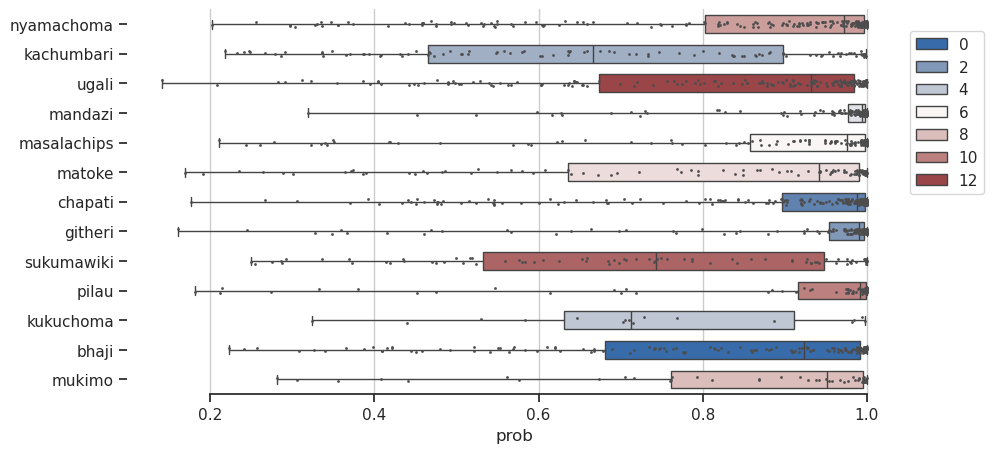

In [123]:
# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(10, 5))

_ = sns.boxplot(
    df_output, x="prob", y="class", hue="class_id",
    whis=[0, 100], width=.6, palette="vlag"
)

# Add in points to show each observation
_ = sns.stripplot(df_output, x="prob", y="class", size=2, color=".3")

# Tweak the visual presentation
_ = ax.legend(loc='lower left', bbox_to_anchor=(1, 0.5), ncol=1)   
_ = ax.xaxis.grid(True)
_ = ax.set(ylabel="")
sns.despine(trim=True, left=True)

In [124]:
input_df = pd.read_csv('my_inference_1.csv')
input_df.head()

,id,class,class_id,prob
0,9156739011499789258,nyamachoma,9,0.886029
1,2049465964503133373,kachumbari,3,0.492616
2,6446998501027132988,nyamachoma,9,0.996924
3,4194396063119815321,ugali,12,0.998227
4,9018117998187006009,mandazi,5,0.724125


In [125]:
input_df.to_csv('my_inference_1_submission.csv', index=False, columns=['id', 'class'])

In [126]:
input_df = pd.read_csv('my_inference_1_submission.csv')
input_df.head(10)

,id,class
0,9156739011499789258,nyamachoma
1,2049465964503133373,kachumbari
2,6446998501027132988,nyamachoma
3,4194396063119815321,ugali
4,9018117998187006009,mandazi
5,6246759883907852128,masalachips
6,16478122708528316044,nyamachoma
7,14045745760440690312,kachumbari
8,7872954221890963019,matoke
9,4868486697531317477,chapati


In [127]:
input_df.tail(10)

,id,class
1628,7596268598227627643,ugali
1629,1704933171119356655,nyamachoma
1630,9262750812933300107,masalachips
1631,4858510207088946382,nyamachoma
1632,5807637199214953403,nyamachoma
1633,18302448610371772604,githeri
1634,15920672464676076400,chapati
1635,3232020170382870007,chapati
1636,3094804487341098468,kachumbari
1637,5827342261332058667,sukumawiki
